# RAMA Integration into RelGNN: Statistical Analysis Demo

**Experiment:** Comparing RelGNN+sum (baseline) vs RelGNN+RAMA (Rank-Aware Moment Aggregation) on two RelBench regression tasks: `rel-f1/driver-position` and `rel-amazon/item-ltv`.

**What this notebook does:**
1. Loads pre-computed experiment results (5 seeds x 2 methods x 2 tasks = 20 runs)
2. Reproduces the statistical analysis: Cohen's d effect sizes, confidence intervals, paired t-tests, and Wilcoxon signed-rank tests
3. Runs DerSimonian-Laird random-effects meta-analysis across tasks
4. Visualizes MAE comparisons and effect size forest plots

RAMA enriches mean pooling with gated per-dimension variance conditioned on spectral rank proxy and cardinality.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages used are pre-installed on Colab; install locally to match Colab env
# scipy==1.16.3 requires Python >=3.11 (Colab); fall back to 1.15.3 for Python 3.10
if 'google.colab' not in sys.modules:
    _scipy = 'scipy==1.16.3' if sys.version_info >= (3, 11) else 'scipy==1.15.3'
    _pip('numpy==2.0.2', 'pandas==2.2.2', _scipy, 'matplotlib==3.10.0')


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import os
import warnings
from collections import defaultdict
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

warnings.filterwarnings("ignore")

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-outputs/ai-invention-9b0386-rank-aware-moment-aggregation-diversity-/main/experiment_iter3_rama_integratio/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f: return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded experiment: {data['metadata']['experiment']}")
print(f"Architecture: {data['metadata']['architecture_used']}")
print(f"Tasks: {data['metadata']['tasks']}")
print(f"Total runs: {len(data['per_run_results'])}")
print(f"Original runtime: {data['metadata']['total_runtime_seconds']:.0f}s")

Loaded experiment: RAMA Integration: RelGNN vs baseline on rel-f1 and rel-amazon
Architecture: RelGNN
Tasks: ['rel-f1/driver-position', 'rel-amazon/item-ltv']
Total runs: 20
Original runtime: 8445s


In [5]:
# ── Config: experiment parameters (from original run) ──
# These mirror the original experiment's hyperparameters for reference.
# The statistical analysis below is parameterized by ALPHA.

SEEDS = [42, 123, 456, 789, 1024]  # Original: [42, 123, 456, 789, 1024]
LR = 0.005                          # Original: 0.005
EPOCHS = 10                          # Original: 10
MAX_STEPS_PER_EPOCH = 2000           # Original: 2000
CHANNELS = 128                       # Original: 128
RAMA_GATE_HIDDEN = 16                # Original: 16
ALPHA = 0.05                         # Significance level for CI computation

METHODS = {
    "relgnn_sum":  {"use_rama": False, "label": "RelGNN+sum (original)"},
    "relgnn_rama": {"use_rama": True,  "label": "RelGNN+RAMA"},
}

print(f"Config: {len(SEEDS)} seeds, {EPOCHS} epochs, alpha={ALPHA}")

Config: 5 seeds, 10 epochs, alpha=0.05


## Statistical Analysis Functions

These functions are copied directly from the original `method.py` script. They compute:
- **Cohen's d**: Standardized effect size between baseline and RAMA MAE distributions
- **Cohen's d CI**: 95% confidence interval using non-central t approximation
- **DerSimonian-Laird**: Random-effects meta-analysis pooling effect sizes across tasks

In [6]:
def cohens_d(x: List[float], y: List[float]) -> float:
    """Cohen's d (positive = x > y, for MAE: positive = RAMA better)."""
    nx, ny = len(x), len(y)
    mx, my = np.mean(x), np.mean(y)
    sx, sy = np.std(x, ddof=1), np.std(y, ddof=1)
    pooled = np.sqrt(((nx-1)*sx**2 + (ny-1)*sy**2) / (nx+ny-2))
    if pooled < 1e-12:
        return 0.0
    return (mx - my) / pooled


def cohens_d_ci(d: float, n1: int, n2: int, alpha: float = 0.05) -> List[float]:
    """95% CI for Cohen's d using non-central t approximation."""
    se = np.sqrt(n1 + n2) / np.sqrt(n1 * n2) * np.sqrt(1 + d**2 * n1 * n2 / (2 * (n1 + n2)))
    t_crit = stats.t.ppf(1 - alpha/2, n1 + n2 - 2)
    return [d - t_crit * se, d + t_crit * se]


def dersimonian_laird(effects: List[float], variances: List[float]) -> dict:
    """DerSimonian-Laird random-effects meta-analysis."""
    k = len(effects)
    if k == 0:
        return {"pooled_effect": 0, "pooled_se": 0, "tau2": 0, "I2": 0}
    w = [1.0/v if v > 0 else 0 for v in variances]
    W = sum(w)
    if W < 1e-12:
        return {"pooled_effect": np.mean(effects), "pooled_se": 1.0,
                "tau2": 0, "I2": 0}
    theta_fe = sum(wi * ei for wi, ei in zip(w, effects)) / W
    Q = sum(wi * (ei - theta_fe)**2 for wi, ei in zip(w, effects))
    C = W - sum(wi**2 for wi in w) / W
    tau2 = max(0, (Q - (k - 1)) / C) if C > 0 else 0
    w_re = [1.0 / (v + tau2) if (v + tau2) > 0 else 0 for v in variances]
    W_re = sum(w_re)
    if W_re < 1e-12:
        return {"pooled_effect": np.mean(effects), "pooled_se": 1.0,
                "tau2": tau2, "I2": 0}
    theta_re = sum(wi * ei for wi, ei in zip(w_re, effects)) / W_re
    se_re = 1.0 / np.sqrt(W_re)
    I2 = max(0, (Q - (k-1)) / Q * 100) if Q > 0 else 0
    return {"pooled_effect": float(theta_re), "pooled_se": float(se_re),
            "tau2": float(tau2), "I2": float(I2)}

print("Statistical functions defined.")

Statistical functions defined.


## Per-Task Statistical Analysis

Extract baseline (RelGNN+sum) and RAMA MAE values per task, then compute Cohen's d effect sizes, paired t-tests, and Wilcoxon signed-rank tests.

In [7]:
# Extract per-task results from loaded data
all_results = data["per_run_results"]
task_names = data["metadata"]["tasks"]
all_task_stats = {}

for task_key in task_names:
    task_runs = [r for r in all_results if r["task"] == task_key]
    baseline_maes = [r["test_mae"] for r in task_runs
                     if not METHODS[r["config"]]["use_rama"]]
    rama_maes = [r["test_mae"] for r in task_runs
                 if METHODS[r["config"]]["use_rama"]]

    if len(baseline_maes) >= 2 and len(rama_maes) >= 2:
        d = cohens_d(baseline_maes, rama_maes)
        ci = cohens_d_ci(d, len(baseline_maes), len(rama_maes), alpha=ALPHA)
        n_paired = min(len(baseline_maes), len(rama_maes))
        try:
            t_stat, p_val = stats.ttest_rel(
                baseline_maes[:n_paired], rama_maes[:n_paired])
        except Exception:
            t_stat, p_val = 0.0, 1.0
        try:
            w_stat, w_pval = stats.wilcoxon(
                baseline_maes[:n_paired], rama_maes[:n_paired])
        except Exception:
            w_stat, w_pval = 0.0, 1.0

        bm = np.mean(baseline_maes)
        rm = np.mean(rama_maes)
        pct = (bm - rm) / bm * 100 if bm > 0 else 0

        task_stat = {
            "baseline_maes": baseline_maes,
            "rama_maes": rama_maes,
            "baseline_mean": float(bm),
            "baseline_std": float(np.std(baseline_maes, ddof=1)),
            "rama_mean": float(rm),
            "rama_std": float(np.std(rama_maes, ddof=1)),
            "cohens_d": float(d),
            "cohens_d_ci_95": [float(x) for x in ci],
            "paired_ttest_t": float(t_stat),
            "paired_ttest_p": float(p_val),
            "wilcoxon_stat": float(w_stat),
            "wilcoxon_p": float(w_pval),
            "improvement_pct": float(pct),
        }
        all_task_stats[task_key] = task_stat

        print(f"\n=== {task_key} ===")
        print(f"  Baseline MAE: {bm:.4f} +/- {np.std(baseline_maes, ddof=1):.4f}")
        print(f"  RAMA MAE:     {rm:.4f} +/- {np.std(rama_maes, ddof=1):.4f}")
        print(f"  Cohen's d:    {d:.4f} [{ci[0]:.4f}, {ci[1]:.4f}]")
        print(f"  Paired t-test p-value: {p_val:.6f}")
        print(f"  Wilcoxon p-value:      {w_pval:.4f}")
        print(f"  Improvement:  {pct:.2f}%")


=== rel-f1/driver-position ===
  Baseline MAE: 4.2813 +/- 0.2730
  RAMA MAE:     4.3757 +/- 0.2675
  Cohen's d:    -0.3493 [-1.9150, 1.2164]
  Paired t-test p-value: 0.560386
  Wilcoxon p-value:      0.8125
  Improvement:  -2.20%

=== rel-amazon/item-ltv ===
  Baseline MAE: 57.5738 +/- 1.6942
  RAMA MAE:     57.9899 +/- 0.8629
  Cohen's d:    -0.3095 [-1.8528, 1.2338]
  Paired t-test p-value: 0.429774
  Wilcoxon p-value:      0.6250
  Improvement:  -0.72%


## Cross-Task Meta-Analysis

Pool effect sizes across tasks using the DerSimonian-Laird random-effects model. This accounts for potential heterogeneity between tasks.

In [8]:
# Cross-task meta-analysis (DerSimonian-Laird)
effects = []
variances = []
for tk, ts in all_task_stats.items():
    effects.append(ts["cohens_d"])
    n = len(ts["baseline_maes"])
    se = np.sqrt(2.0/n + ts["cohens_d"]**2 / (2*n))
    variances.append(se**2)

meta = dersimonian_laird(effects, variances)

print("=" * 50)
print("Cross-task Meta-Analysis (DerSimonian-Laird)")
print("=" * 50)
print(f"  Pooled effect (d): {meta['pooled_effect']:.4f} (SE={meta['pooled_se']:.4f})")
print(f"  tau^2 = {meta['tau2']:.4f}")
print(f"  I^2   = {meta['I2']:.1f}%")
print(f"  95% CI: [{meta['pooled_effect'] - 1.96*meta['pooled_se']:.4f}, "
      f"{meta['pooled_effect'] + 1.96*meta['pooled_se']:.4f}]")

# Compare with iter_2 HeteroSAGE results
comparison = data["metadata"]["comparison_with_heterosage"]
print(f"\n--- Comparison with iter_2 HeteroSAGE+RAMA ---")
for tk, comp in comparison.items():
    print(f"  {tk}: HeteroSAGE d={comp['heterosage_rama_cohens_d']:.2f} | {comp['note']}")

Cross-task Meta-Analysis (DerSimonian-Laird)
  Pooled effect (d): -0.3293 (SE=0.4533)
  tau^2 = 0.0000
  I^2   = 0.0%
  95% CI: [-1.2177, 0.5590]

--- Comparison with iter_2 HeteroSAGE+RAMA ---
  rel-f1/driver-position: HeteroSAGE d=-0.50 | RAMA was worse with HeteroSAGE on F1
  rel-amazon/item-ltv: HeteroSAGE d=10.83 | RAMA was dramatically better with HeteroSAGE on Amazon


## Results Summary Table

Print a concise results table showing per-task and meta-analysis statistics.

In [9]:
# Print results summary table
header = f"{'Task':<28} {'Baseline MAE':>14} {'RAMA MAE':>14} {'d':>8} {'p-val':>8} {'Improv%':>8}"
print(header)
print("-" * len(header))
for tk, ts in all_task_stats.items():
    short_tk = tk.split("/")[-1]
    print(f"{tk:<28} "
          f"{ts['baseline_mean']:>7.2f}+/-{ts['baseline_std']:.2f} "
          f"{ts['rama_mean']:>7.2f}+/-{ts['rama_std']:.2f} "
          f"{ts['cohens_d']:>8.3f} "
          f"{ts['paired_ttest_p']:>8.4f} "
          f"{ts['improvement_pct']:>7.2f}%")
print("-" * len(header))
print(f"{'Meta-analysis (pooled)':<28} {'':>14} {'':>14} "
      f"{meta['pooled_effect']:>8.3f} {'':>8} {'':>8}")
print(f"\nI^2 = {meta['I2']:.1f}% (heterogeneity between tasks)")

# Per-run details
print(f"\n{'='*70}")
print("Per-run test MAE values:")
print(f"{'='*70}")
for tk in task_names:
    print(f"\n  {tk}:")
    task_runs = [r for r in all_results if r["task"] == tk]
    for r in sorted(task_runs, key=lambda x: (x["config"], x["seed"])):
        marker = "*" if METHODS[r["config"]]["use_rama"] else " "
        print(f"    {marker} {r['label']:<25} seed={r['seed']:<5} "
              f"MAE={r['test_mae']:.4f}  params={r['num_params']:,}")

Task                           Baseline MAE       RAMA MAE        d    p-val  Improv%
-------------------------------------------------------------------------------------
rel-f1/driver-position          4.28+/-0.27    4.38+/-0.27   -0.349   0.5604   -2.20%
rel-amazon/item-ltv            57.57+/-1.69   57.99+/-0.86   -0.309   0.4298   -0.72%
-------------------------------------------------------------------------------------
Meta-analysis (pooled)                                       -0.329                  

I^2 = 0.0% (heterogeneity between tasks)

Per-run test MAE values:

  rel-f1/driver-position:
    * RelGNN+RAMA               seed=42    MAE=4.5000  params=10,568,753
    * RelGNN+RAMA               seed=123   MAE=4.6656  params=10,568,753
    * RelGNN+RAMA               seed=456   MAE=4.0796  params=10,568,753
    * RelGNN+RAMA               seed=789   MAE=4.1022  params=10,568,753
    * RelGNN+RAMA               seed=1024  MAE=4.5313  params=10,568,753
      RelGNN+sum (origin

## Visualization

Three plots:
1. **MAE Comparison**: Bar chart comparing baseline vs RAMA MAE per task (with error bars)
2. **Forest Plot**: Cohen's d effect sizes with 95% CIs per task + pooled meta-analysis estimate
3. **Training Loss Curves**: Average training loss over epochs for each method/task combination

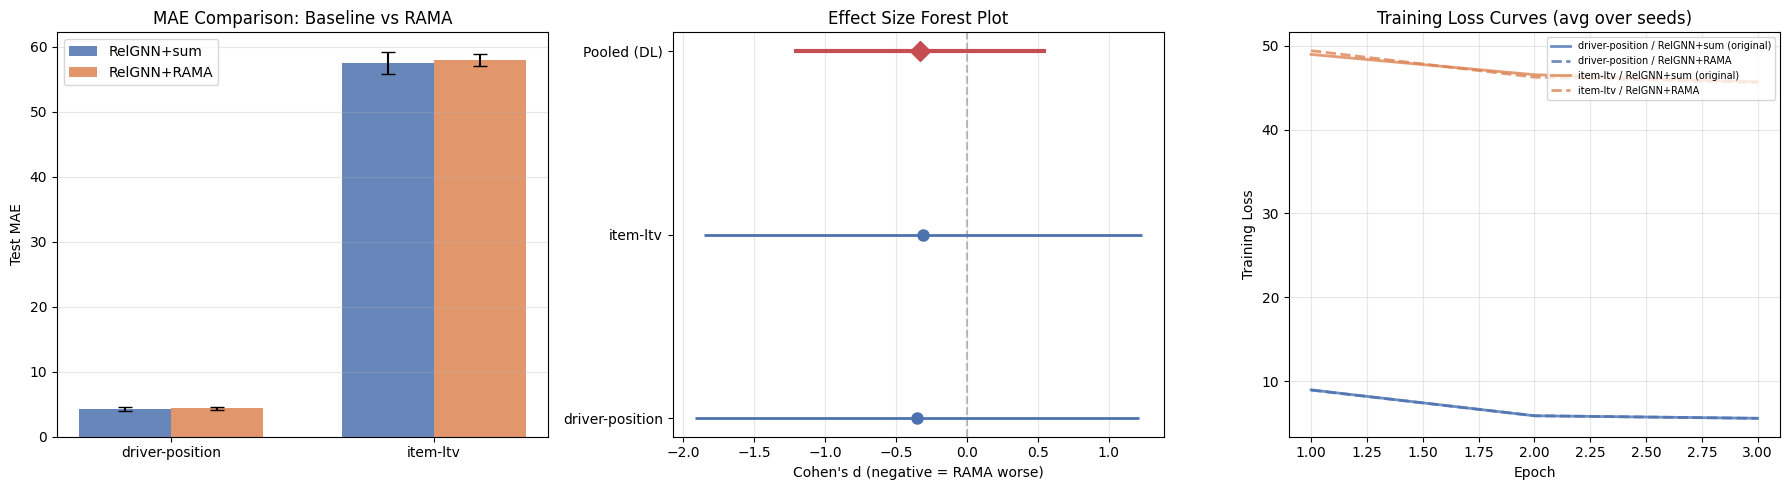

Saved results_visualization.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: MAE Comparison Bar Chart ──
ax = axes[0]
task_labels = [tk.split("/")[-1] for tk in all_task_stats.keys()]
baseline_means = [ts["baseline_mean"] for ts in all_task_stats.values()]
baseline_stds = [ts["baseline_std"] for ts in all_task_stats.values()]
rama_means = [ts["rama_mean"] for ts in all_task_stats.values()]
rama_stds = [ts["rama_std"] for ts in all_task_stats.values()]

x = np.arange(len(task_labels))
width = 0.35
bars1 = ax.bar(x - width/2, baseline_means, width, yerr=baseline_stds,
               label="RelGNN+sum", color="#4C72B0", capsize=5, alpha=0.85)
bars2 = ax.bar(x + width/2, rama_means, width, yerr=rama_stds,
               label="RelGNN+RAMA", color="#DD8452", capsize=5, alpha=0.85)
ax.set_ylabel("Test MAE")
ax.set_title("MAE Comparison: Baseline vs RAMA")
ax.set_xticks(x)
ax.set_xticklabels(task_labels)
ax.legend()
ax.grid(axis="y", alpha=0.3)

# ── Plot 2: Forest Plot of Effect Sizes ──
ax = axes[1]
task_keys = list(all_task_stats.keys())
y_pos = list(range(len(task_keys) + 1))  # +1 for pooled
labels = [tk.split("/")[-1] for tk in task_keys] + ["Pooled (DL)"]

for i, tk in enumerate(task_keys):
    ts = all_task_stats[tk]
    d = ts["cohens_d"]
    ci_lo, ci_hi = ts["cohens_d_ci_95"]
    ax.plot(d, i, "o", color="#4C72B0", markersize=8, zorder=5)
    ax.hlines(i, ci_lo, ci_hi, colors="#4C72B0", linewidths=2, zorder=4)

# Pooled estimate
pooled_ci_lo = meta["pooled_effect"] - 1.96 * meta["pooled_se"]
pooled_ci_hi = meta["pooled_effect"] + 1.96 * meta["pooled_se"]
ax.plot(meta["pooled_effect"], len(task_keys), "D", color="#C44E52",
        markersize=10, zorder=5)
ax.hlines(len(task_keys), pooled_ci_lo, pooled_ci_hi,
          colors="#C44E52", linewidths=3, zorder=4)

ax.axvline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel("Cohen's d (negative = RAMA worse)")
ax.set_title("Effect Size Forest Plot")
ax.grid(axis="x", alpha=0.3)

# ── Plot 3: Training Loss Curves ──
ax = axes[2]
for task_key in task_names:
    for config_name, mcfg in METHODS.items():
        runs = [r for r in all_results
                if r["task"] == task_key and r["config"] == config_name]
        if not runs:
            continue
        # Average training losses across seeds
        max_len = max(len(r["train_losses"]) for r in runs)
        avg_losses = []
        for ep in range(max_len):
            vals = [r["train_losses"][ep] for r in runs if ep < len(r["train_losses"])]
            avg_losses.append(np.mean(vals))
        short_task = task_key.split("/")[-1]
        style = "--" if mcfg["use_rama"] else "-"
        color = "#DD8452" if "amazon" in task_key else "#4C72B0"
        ax.plot(range(1, len(avg_losses)+1), avg_losses, style, color=color,
                linewidth=2, alpha=0.8,
                label=f"{short_task} / {mcfg['label']}")

ax.set_xlabel("Epoch")
ax.set_ylabel("Training Loss")
ax.set_title("Training Loss Curves (avg over seeds)")
ax.legend(fontsize=7, loc="upper right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("results_visualization.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved results_visualization.png")